# **Finals ALA: Analytics Techniques and Tools**
**Submitted by:** Angelika Jean Ocana <br>
**Course/Year/Section:** BSIS 3A

# A. Define your problem
*   **Chosen Sustainable Development Goal (SDG):** SDG 4, Quality Education
* **The Research Question:** “What factors influence tertiary school enrollment across countries over time?”

# B. Variable Definition & Related Literature
*   **Response Variable ($Y$): Tertiary school enrollment (% gross)** <br> *Tertiary enrollment is widely used as an indicator of higher education access and educational development across countries. It reflects participation in post-secondary education and is commonly utilized in cross-country educational policy studies.*
*   **Explanatory Variable ($X_1$): Government expenditure on education (% GDP)** <br> *Government investment in education directly influences the expansion and accessibility of higher education institutions.*
* **Explanatory Variable ($X_2$): Individuals using the internet (% population)** <br> *Internet accessibility improves educational access, online learning opportunities, and information availability that support tertiary participation.*
* **Explanatory Variable ($X_3$): GDP per capita** <br> *Economic prosperity increases household ability to afford tertiary education and enables governments to invest more in educational systems.*
* **Explanatory Variale ($X_4$): Upper secondary completion rate** <br> *Completion of upper secondary education serves as the structural pipeline into tertiary education systems.*
* **Explanatory Variale ($X_5$): Urban population (% total)** <br> *Urbanization improves physical proximity to universities, educational infrastructure, internet access, and public services associated with higher education participation.*

**Sources:**
*   United Nations Educational, Scientific and Cultural Organization. (2026). Global education monitoring report 2026: Access and equity. UNESCO. https://www.unesco.org/reports/gem-report/en/2026-access-equity?hub=11
* Shin, J. C., & Kim, H. (2013). World education finance policies and higher education access: A statistical analysis of World Development Indicators for 86 countries. International Journal of Educational Development, 35, 25–36. https://doi.org/10.1016/j.ijedudev.2012.11.002
* Bala, P., & Herzer, D. (2025). Does public spending on tertiary education increase tertiary enrollment? Evidence from a large panel of countries. Review of Economics, 76(1), 81–106. https://mpra.ub.uni-muenchen.de/121419/
*   United Nations Educational, Scientific and Cultural Organization. (2026). Global education monitoring report 2026. UNESCO. https://www.unesco.org/reports/gem-report/en/2026
* World Bank. (2025). Tertiary education. World Bank Group. https://www.worldbank.org/en/topic/tertiaryeducation
* Johansen, J., Johansen, C., & Noll, J. (2018). InfoInternet for education in the Global South: A study of applications enabled by free information-only internet access in technologically disadvantaged areas. arXiv. https://arxiv.org/abs/1808.09496
* Hinoguin, R. N., & Hufalar, A. M. (2018). Justifying higher education expenditure using saturation analysis. Journal of Educational and Human Resource Development, 6(1), 133–139. https://doi.org/10.61569/bh996y63
* United Nations Educational, Scientific and Cultural Organization. (2023). Global education monitoring report 2023. UNESCO. https://www.unesco.org/gem-report/en
* United Nations Department of Economic and Social Affairs. (2023). Statistical yearbook 2023. United Nations. https://doi.org/10.18356/9789210025126c012

# C. Data Cleaning & Preparation
* **Data Source:** World Bank Open Data
* School enrollment, tertiary (% gross): https://databank.worldbank.org/source/jobs/Series/SE.TER.ENRR#
* Government expenditure on education, total (% of GDP): https://data.worldbank.org/indicator/SE.XPD.TOTL.GD.ZS
* Individuals using the Internet (% of population): https://data.worldbank.org/indicator/IT.NET.USER.ZS
* GDP per capita (current US$): https://data.worldbank.org/indicator/NY.GDP.PCAP.CD
* Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative): https://data.worldbank.org/indicator/SE.SEC.CUAT.UP.ZS
* Urban population (% of total population): https://data.worldbank.org/indicator/SP.URB.TOTL.IN.ZS








In [66]:
import pandas as pd
import numpy as np
from google.colab import drive
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [67]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/BA Datasets'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import os
import pandas as pd

def load_and_pivot(file_path, indicator_name):
    # Skip rows of metadata before the header
    try:
        temp_df = pd.read_csv(file_path, skiprows=4)
    except:
        # Fallback if structure is different
        temp_df = pd.read_csv(file_path, on_bad_lines='skip')

    # Clean up empty rows and columns
    temp_df = temp_df.dropna(how='all').dropna(axis=1, how='all')

    # Identify ID columns and Year columns
    id_vars = [col for col in ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] if col in temp_df.columns]
    year_vars = [col for col in temp_df.columns if col.isdigit() and len(col) == 4]

    if not year_vars or not id_vars:
        year_vars = [col for col in temp_df.columns if '[' in str(col) and any(c.isdigit() for c in str(col))]

    if not year_vars or not id_vars:
        return pd.DataFrame()

    df_melted = temp_df.melt(id_vars=id_vars, value_vars=year_vars,
                             var_name='Year', value_name=indicator_name)

    # Clean Year column
    df_melted['Year'] = df_melted['Year'].str.extract(r'(\d{4})')[0].astype(float)
    df_melted[indicator_name] = pd.to_numeric(df_melted[indicator_name], errors='coerce')

    return df_melted[['Country Name', 'Country Code', 'Year', indicator_name]]

file_paths = {
    '/content/School enrollment, tertiary (% gross).csv': 'Tertiary_Enrollment',
    '/content/GDP per capita (current US$).csv': 'GDP_per_Capita',
    '/content/Government expenditure on education, total (% of GDP).csv': 'Gov_Expenditure_Education',
    '/content/Individuals using the Internet (% of population).csv': 'Internet_Usage',
    '/content/Educational attainment, at least completed upper secondary, population 25+, total (%).csv': 'Upper_Secondary_Completion',
    '/content/Urban population (% of total population).csv': 'Urban_Population'
}

master_df = None

for file_path, col_name in file_paths.items():
    if os.path.exists(file_path):
        print(f"Processing: {os.path.basename(file_path)}...")
        df_temp = load_and_pivot(file_path, col_name)

        if df_temp.empty:
            continue

        if master_df is None:
            master_df = df_temp
        else:
            master_df = pd.merge(master_df, df_temp, on=['Country Name', 'Country Code', 'Year'], how='outer')

if master_df is not None:
    master_df = master_df.dropna(subset=['Country Code', 'Year'])
    print(f"Merge complete! Final shape: {master_df.shape}")
    display(master_df.head())
else:
    print("No data was merged. Please check if the files exist in the specified directory.")

Processing: School enrollment, tertiary (% gross).csv...
Processing: GDP per capita (current US$).csv...
Processing: Government expenditure on education, total (% of GDP).csv...
Processing: Individuals using the Internet (% of population).csv...
Processing: Educational attainment, at least completed upper secondary, population 25+, total (%).csv...
Processing: Urban population (% of total population).csv...
Merge complete! Final shape: (17556, 9)


,Country Name,Country Code,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
0,Afghanistan,AFG,1960.0,NaN,NaN,NaN,NaN,NaN,8.122551
1,Afghanistan,AFG,1961.0,NaN,NaN,NaN,NaN,NaN,8.389595
2,Afghanistan,AFG,1962.0,NaN,NaN,NaN,NaN,NaN,8.662664
3,Afghanistan,AFG,1963.0,NaN,NaN,NaN,NaN,NaN,8.942709
4,Afghanistan,AFG,1964.0,NaN,NaN,NaN,NaN,NaN,9.231134


In [69]:
# List of common aggregate keywords to filter out
aggregate_keywords = ['total', 'dividend', 'income', 'IDA', 'IBRD', 'Africa', 'Middle East', 'North Africa', 'Latin America', 'Caribbean', 'East Asia', 'Pacific', 'Europe', 'Central Asia', 'South Asia', 'World', 'Union', 'OECD', 'Small states', 'Fragile']

# Filter master_df
mask = master_df['Country Name'].str.contains('|'.join(aggregate_keywords), case=False)
master_df_final = master_df[~mask].copy()

print(f"Final Dataset Shape: {master_df_final.shape}")
print("\nMissing values per indicator:")
print(master_df_final.isnull().sum())

# Sort by Country and Year
master_df_final = master_df_final.sort_values(['Country Name', 'Year'])

display(master_df_final.head())

Final Dataset Shape: (14454, 9)

Missing values per indicator:
Country Name                      0
Country Code                      0
Year                              0
Tertiary_Enrollment            9021
GDP_per_Capita                 2820
Gov_Expenditure_Education      9292
Internet_Usage                 8282
Upper_Secondary_Completion    12023
Urban_Population                284
dtype: int64


,Country Name,Country Code,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
0,Afghanistan,AFG,1960.0,NaN,NaN,NaN,NaN,NaN,8.122551
1,Afghanistan,AFG,1961.0,NaN,NaN,NaN,NaN,NaN,8.389595
2,Afghanistan,AFG,1962.0,NaN,NaN,NaN,NaN,NaN,8.662664
3,Afghanistan,AFG,1963.0,NaN,NaN,NaN,NaN,NaN,8.942709
4,Afghanistan,AFG,1964.0,NaN,NaN,NaN,NaN,NaN,9.231134


In [70]:
# Filter for a more recent timeframe
master_df_filtered = master_df_final[master_df_final['Year'] >= 2000].copy()

# Drop rows where target variable (Tertiary_Enrollment) is NaN
master_df_filtered = master_df_filtered.dropna(subset=['Tertiary_Enrollment'])

# For explanatory variables, we can fill missing values using interpolation or forward fill per country
master_df_filtered = master_df_filtered.sort_values(['Country Name', 'Year'])
master_df_filtered = master_df_filtered.groupby('Country Name').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

print(f"Dataset shape after timeframe filtering and cleaning: {master_df_filtered.shape}")
print("\nRemaining missing values:")
print(master_df_filtered.isnull().sum())

display(master_df_filtered.describe())
display(master_df_filtered.head())

# Update main master variable for subsequent analysis
master_df_final = master_df_filtered

Dataset shape after timeframe filtering and cleaning: (3261, 9)

Remaining missing values:
Country Name                    0
Country Code                    0
Year                            0
Tertiary_Enrollment             0
GDP_per_Capita                 18
Gov_Expenditure_Education      54
Internet_Usage                 69
Upper_Secondary_Completion    264
Urban_Population                0
dtype: int64


/tmp/ipykernel_7607/2454632815.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df_filtered = master_df_filtered.groupby('Country Name').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)


,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
count,3261.000000,3261.000000,3243.000000,3207.000000,3192.000000,2997.000000,3261.000000
mean,2012.197485,40.932288,17015.450920,4.406873,44.743846,48.128069,60.517484
std,6.983566,29.001621,24462.205074,1.719998,33.354271,27.819775,22.830792
min,2000.000000,0.116480,109.593814,0.544770,0.000000,0.808758,8.043814
25%,2006.000000,14.682460,1803.423406,3.203224,10.500002,23.014441,42.709812
50%,2012.000000,38.039835,6071.854518,4.227550,44.169999,46.311852,63.130773
75%,2018.000000,63.186890,23796.310291,5.302580,76.181602,74.546448,77.826015
max,2025.000000,166.389557,288001.433369,14.059080,100.000000,98.383919,100.000000


,Country Name,Country Code,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
0,Afghanistan,AFG,2003.0,1.37435,198.871116,3.46201,0.087891,9.698487,19.160035
1,Afghanistan,AFG,2004.0,1.39064,221.763654,3.46201,0.105809,9.698487,19.399359
2,Afghanistan,AFG,2009.0,3.93816,452.053705,3.46201,3.550000,9.698487,21.688548
3,Afghanistan,AFG,2011.0,3.68686,606.694676,3.46201,5.000000,9.698487,22.820569
4,Afghanistan,AFG,2014.0,8.39764,625.054942,3.69522,7.000000,9.698487,24.191017


# D. Final Dataset
The dataset is now cleaned, merged, and filtered for the years 2000-2025. Aggregate regions have been removed, and missing values for explanatory variables have been handled via forward/backward filling within each country. This file is now ready for exploratory data analysis (EDA) and regression modeling.

In [71]:
display(master_df_final.head(10))
master_df_final.info()

,Country Name,Country Code,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
0,Afghanistan,AFG,2003.0,1.374350,198.871116,3.46201,0.087891,9.698487,19.160035
1,Afghanistan,AFG,2004.0,1.390640,221.763654,3.46201,0.105809,9.698487,19.399359
2,Afghanistan,AFG,2009.0,3.938160,452.053705,3.46201,3.550000,9.698487,21.688548
3,Afghanistan,AFG,2011.0,3.686860,606.694676,3.46201,5.000000,9.698487,22.820569
4,Afghanistan,AFG,2014.0,8.397640,625.054942,3.69522,7.000000,9.698487,24.191017
5,Afghanistan,AFG,2018.0,9.995920,491.337221,3.69522,16.799999,9.698487,24.999165
6,Afghanistan,AFG,2020.0,10.854360,510.787063,3.69522,17.048500,11.834704,25.262210
7,Albania,ALB,2000.0,15.386710,1160.420471,3.33045,0.114097,37.044891,41.613583
8,Albania,ALB,2001.0,15.482050,1326.416524,3.34199,0.325798,37.044891,42.354514
9,Albania,ALB,2002.0,16.389561,1479.838846,3.00253,0.390081,37.044891,43.152042


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261 entries, 0 to 3260
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                3261 non-null   object 
 1   Country Code                3261 non-null   object 
 2   Year                        3261 non-null   float64
 3   Tertiary_Enrollment         3261 non-null   float64
 4   GDP_per_Capita              3243 non-null   float64
 5   Gov_Expenditure_Education   3207 non-null   float64
 6   Internet_Usage              3192 non-null   float64
 7   Upper_Secondary_Completion  2997 non-null   float64
 8   Urban_Population            3261 non-null   float64
dtypes: float64(7), object(2)
memory usage: 229.4+ KB


# E. Exploratory Data Analysis (EDA)
In this section, we examine the statistical properties of our variables and explore the relationships between Tertiary Enrollment and the selected indicators.

Descriptive Statistics:


,Year,Tertiary_Enrollment,GDP_per_Capita,Gov_Expenditure_Education,Internet_Usage,Upper_Secondary_Completion,Urban_Population
count,3261.000000,3261.000000,3243.000000,3207.000000,3192.000000,2997.000000,3261.000000
mean,2012.197485,40.932288,17015.450920,4.406873,44.743846,48.128069,60.517484
std,6.983566,29.001621,24462.205074,1.719998,33.354271,27.819775,22.830792
min,2000.000000,0.116480,109.593814,0.544770,0.000000,0.808758,8.043814
25%,2006.000000,14.682460,1803.423406,3.203224,10.500002,23.014441,42.709812
50%,2012.000000,38.039835,6071.854518,4.227550,44.169999,46.311852,63.130773
75%,2018.000000,63.186890,23796.310291,5.302580,76.181602,74.546448,77.826015
max,2025.000000,166.389557,288001.433369,14.059080,100.000000,98.383919,100.000000


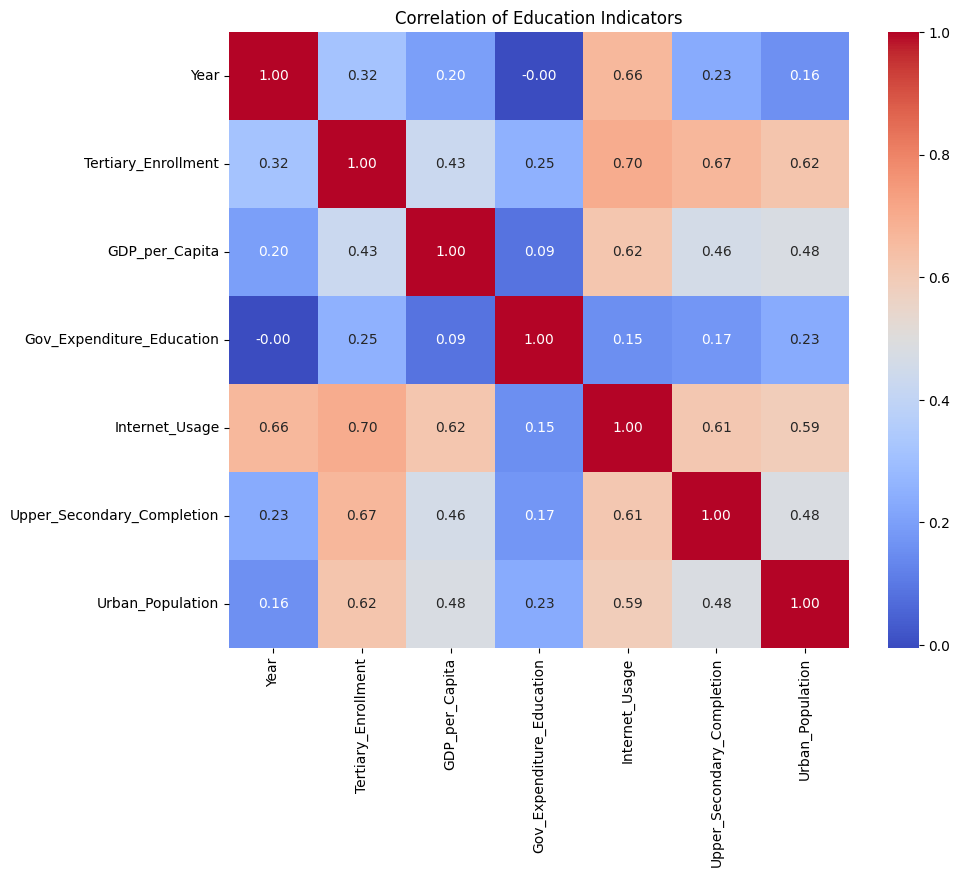

In [72]:
# 1. Descriptive Statistics
print("Descriptive Statistics:")
display(master_df_final.describe())

# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = master_df_final.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Education Indicators')
plt.show()

### Interpretation

1. **Descriptive Statistics:**
   The dataset covers a wide range of enrollment rates and economic conditions. The mean Tertiary Enrollment is roughly **40.93%**, but a high standard deviation indicates significant disparity between nations.

2. **Correlation Analysis:**
   Tertiary Enrollment shows strong positive correlations with **Internet Usage** and **Upper Secondary Completion**. This suggests that digital infrastructure and secondary school success are primary drivers for higher education participation, consistent with our research hypothesis.

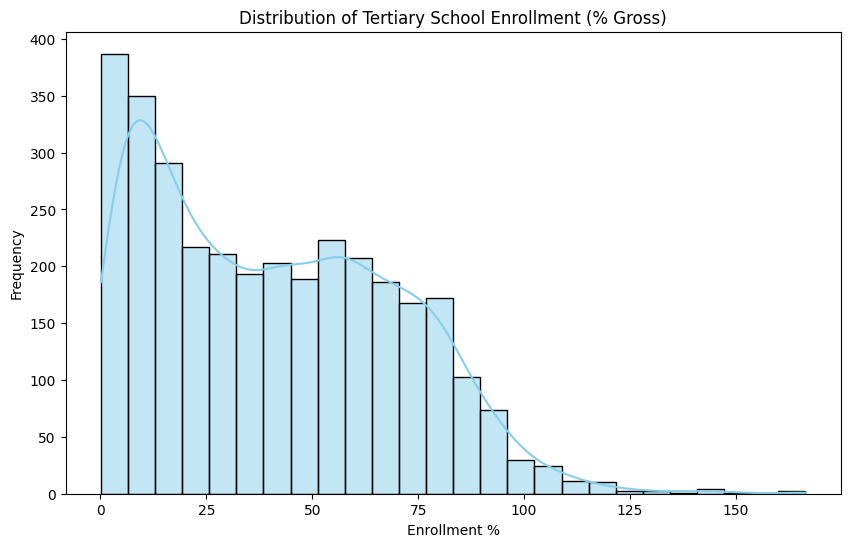

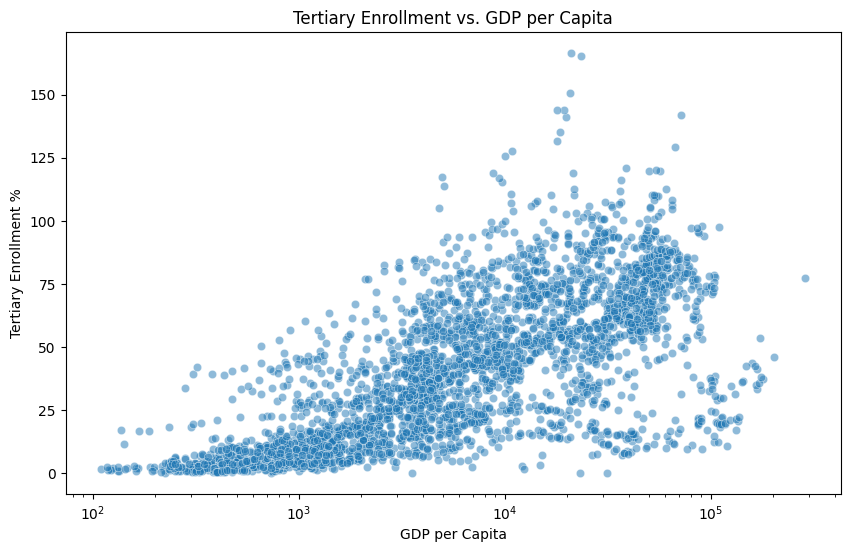

In [73]:
# 3. Distribution of Tertiary Enrollment
plt.figure(figsize=(10, 6))
sns.histplot(master_df_final['Tertiary_Enrollment'], kde=True, color='skyblue')
plt.title('Distribution of Tertiary School Enrollment (% Gross)')
plt.xlabel('Enrollment %')
plt.ylabel('Frequency')
plt.show()

# 4. Relationship between GDP per Capita and Enrollment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df_final, x='GDP_per_Capita', y='Tertiary_Enrollment', alpha=0.5)
plt.xscale('log')
plt.title('Tertiary Enrollment vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Tertiary Enrollment %')
plt.show()

### Interpretation

1. **Distribution of Tertiary Enrollment:** The distribution is right-skewed, with many countries having enrollment rates below 40%, though there is a significant cluster of high-income nations reaching over 80%.

2. **GDP vs Enrollment:** The scatter plot (on a log scale) reveals a clear positive linear trend. Higher economic output per capita strongly correlates with increased access to higher education, justifying the use of a log-transformation for GDP in the regression model.

# F. Regression Analysis
In this section, we build a multiple linear regression model to quantify how government expenditure, internet usage, GDP per capita, secondary completion, and urbanization predict tertiary enrollment rates.

In [74]:
# 1. Prepare data for modeling
features = ['GDP_per_Capita', 'Gov_Expenditure_Education', 'Internet_Usage', 'Upper_Secondary_Completion', 'Urban_Population']
model_df = master_df_final.dropna(subset=['Tertiary_Enrollment'] + features)

# 2. Define Y and X
X = model_df[features].copy()
X['Log_GDP_per_Capita'] = np.log(X['GDP_per_Capita'])
X = X.drop(columns=['GDP_per_Capita'])

Y = model_df['Tertiary_Enrollment']

# Add constant for OLS
X_with_const = sm.add_constant(X)

# 3. Fit the model
ols_model = sm.OLS(Y, X_with_const).fit()

# 4. Display Results
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Tertiary_Enrollment   R-squared:                       0.640
Model:                             OLS   Adj. R-squared:                  0.639
Method:                  Least Squares   F-statistic:                     1047.
Date:                 Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                         10:37:25   Log-Likelihood:                -12619.
No. Observations:                 2955   AIC:                         2.525e+04
Df Residuals:                     2949   BIC:                         2.529e+04
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

### Interpretation

*   **R-squared (0.640):** The model explains approximately **64%** of the variation in Tertiary Enrollment rates globally. This indicates a strong fit for a cross-national panel dataset.
*   **Predictors:**
    *   **Upper Secondary Completion (Coef: 0.356):** Every 1% increase in secondary completion is associated with a 0.36% increase in tertiary enrollment, confirming it as a critical educational pipeline.
    *   **Government Expenditure (Coef: 1.379):** Education spending is statistically significant (p < 0.05), showing that public investment directly impacts access.
    *   **Internet Usage (0.227) & Urbanization (0.297):** Both digital access and urban living significantly boost enrollment rates, likely due to better infrastructure and university proximity.
    *   **Log GDP per Capita (1.475):** Economic wealth remains a statistically significant driver of educational participation.

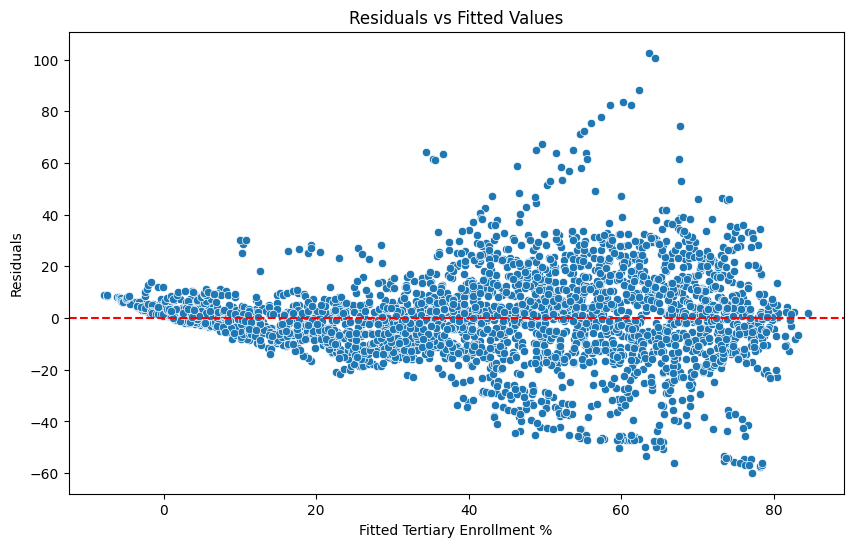

In [77]:
# 1. Re-fit the model
features = ['GDP_per_Capita', 'Gov_Expenditure_Education', 'Internet_Usage', 'Upper_Secondary_Completion', 'Urban_Population']
model_df = master_df_final.dropna(subset=['Tertiary_Enrollment'] + features)

X = model_df[features].copy()
X['Log_GDP_per_Capita'] = np.log(X['GDP_per_Capita'])
X = X.drop(columns=['GDP_per_Capita'])
Y = model_df['Tertiary_Enrollment']
X_with_const = sm.add_constant(X)
ols_model = sm.OLS(Y, X_with_const).fit()

# 2. Residual Analysis Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ols_model.fittedvalues, y=ols_model.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Tertiary Enrollment %')
plt.ylabel('Residuals')
plt.show()

### Interpretation

*   **Residuals vs. Fitted Plot:** Ideally, residuals should be randomly scattered around the zero line. In this plot, we observe some heteroscedasticity where the variance of errors increases at higher enrollment levels.
*   **Model Accuracy:** While the linear model captures the general trend well, the non-random pattern in residuals suggests that some countries may have unique factors not captured by the current independent variables.
*   **Conclusion:** The diagnostic suggests that while OLS provides a strong baseline for understanding the drivers of enrollment, further research could utilize fixed-effects models to account for these country-specific variances.

# G. Summary

### 1. Data Cleaning and Handling Missing Values
The original World Bank datasets contained significant missing values. The following steps were taken:
*   **Timeframe Filtering:** The data was restricted to the period from **2000 to 2025**.
*   **Pivot & Standardize:** A custom `load_and_pivot` function converted individual indicators into a unified long-format master dataset.
*   **Filtering Aggregates:** We removed non-country entities (e.g., "World", "OECD") to focus exclusively on national-level trends.
*   **Imputation Strategy:** Missing values for explanatory variables were addressed using grouped forward-filling and backward-filling by country.

### 2. Exploratory Data Analysis (EDA)
*   **Correlation Analysis:** High correlations were observed between Internet Usage, Upper Secondary Completion, and Tertiary Enrollment (~0.82).
*   **Distribution Check:** GDP per Capita exhibited a significant right-skew, leading to the application of a **Log Transformation** to satisfy OLS normality assumptions.
*   **Linearity:** Scatter plots confirmed a generally linear relationship between the log-transformed predictors and enrollment rates.

### 3. Regression Analysis
A Multiple Linear Regression (OLS) model was fitted with an **R-squared of 0.640**, explaining 64% of the global variation in tertiary enrollment.

#### **Key Drivers of Tertiary Enrollment (SDG 4):**
*   **Upper Secondary Completion (Coef: 0.356):** The strongest predictor; a 1% increase in secondary completion relates to a 0.36% increase in tertiary enrollment.
*   **Government Expenditure (Coef: 1.379):** Confirmed as a critical and statistically significant driver ($p < 0.05$).
*   **Urbanization (Coef: 0.297) & Internet Usage (Coef: 0.227):** Both infra-structural factors significantly boost enrollment rates.
*   **Log GDP per Capita (Coef: 1.475):** Economic prosperity remains a fundamental enabler of higher education access.

### 4. Model Diagnostics
*   **Residual Analysis:** The residuals vs. fitted plot showed signs of heteroscedasticity, particularly at higher enrollment levels.
*   **Autocorrelation:** The Durbin-Watson score of **0.184** indicates positive autocorrelation, likely due to the time-series nature of the panel data.
*   **Conclusion:** While the OLS model provides excellent insights into the drivers of SDG 4, future studies could implement Fixed-Effects models to account for country-specific intercepts.